In [29]:
import sys
sys.path.append('../')
from pathlib import Path
OUTDIR = Path('.')
%load_ext autoreload
%autoreload 2

import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt
import pandas as pd
from library.fd2d import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
from scipy.sparse import *
n = 3
I = np.eye(n)
e = np.ones(n)
T = dia_array(([e, -4.*e, e], [1,0,-1]), shape=(n,n))
S = dia_array(([e,e], [-1,1]), shape=(n,n))
A = kron(T,I) + kron(I,S)



In [4]:
import numpy as np
from scipy.sparse import *
n = 3
I1 = np.eye(n)
I1[0,0]=0
I1[-1,-1]=0
I2 = np.eye(n)

e = np.ones(n)
e1 = np.ones(n)
e1[0] = 0
e2 = np.ones(n)
e2[-1] = 0
e3 = -2.*np.ones(n)
e3[0] = 1
e3[-1] = 1
T = dia_array(([e, -2.*e, e], [1,0,-1]), shape=(n,n))
S = dia_array(([e2,e3, e1], [-1,0,1]), shape=(n,n))
print(I1)
print(S.toarray())

print(kron(I1,T).toarray())
A = kron(I1,T) + kron(S,I)
print(A.toarray())
print(type(A))



[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]
[[ 1.  1.  0.]
 [ 1. -2.  1.]
 [ 0.  1.  1.]]
[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -2.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  1. -2.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. -2.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]]
[[ 1.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  1.  0.  0.  0.]
 [ 1.  0.  0. -4.  1.  0.  1.  0.  0.]
 [ 0.  1.  0.  1. -4.  1.  0.  1.  0.]
 [ 0.  0.  1.  0.  1. -4.  0.  0.  1.]
 [ 0.  0.  0.  1.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  1.]]
<class 'scipy.sparse._bsr.bsr_array'>


In [ ]:
solver = poisson_solver()
N=100
solver.set_grid((0,0),(1,1), N)
h = lambda y: y**2
j = lambda y: y**2+1
k = lambda x: x**2
l = lambda x: x**2 + 1
solver.bc = (h,j,k,l)
f = lambda x,y: 4.
f = np.vectorize(f)
solver.f = f

X, Y, U = solver.solve()
U_exact = X**2 + Y**2


print(np.linalg.norm(U-U_exact, ord=np.inf))

2.7579605266225826e-12


/home/ahn/Programming/Numerical Analysis/finite_difference/../library/fd2d.py:85: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  u = spsolve(self.A,b)


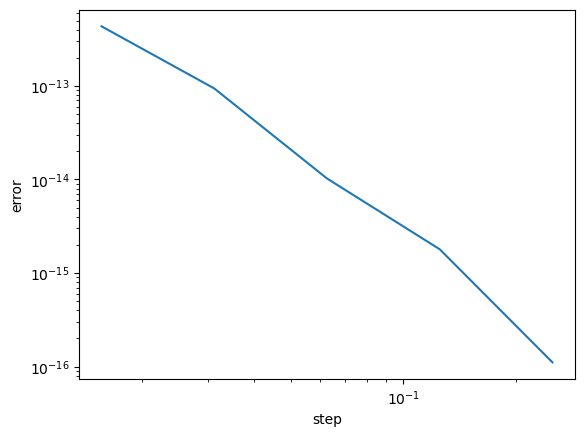

In [30]:
h = lambda y: y**2
j = lambda y: y**2+1
k = lambda x: x**2
l = lambda x: x**2 + 1
step_arr = []
err_arr = []
f = lambda x,y: 4.
f = np.vectorize(f)
for step in 0.25*0.5**np.arange(5):
    N = int(round(1/step))
    solver = poisson_solver()
    solver.set_grid((0,0), (1,1), N)
    solver.bc = (h,j,k,l)
    solver.f = f
    X,Y,U = solver.solve()
    U_exact = X**2 + Y**2
    error = np.linalg.norm(U-U_exact)
    step_arr.append(step)
    err_arr.append(error)
    
fig, ax = plt.subplots()
ax.set_xlabel("step")
ax.set_ylabel("error")
ax.loglog(step_arr, err_arr)

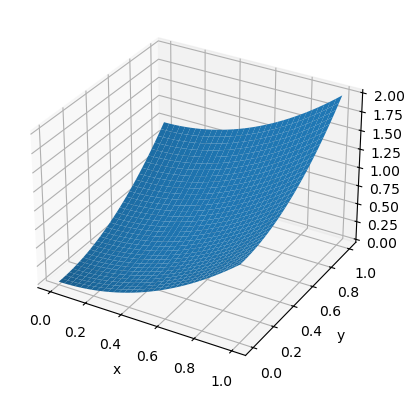

<Figure size 640x480 with 0 Axes>

In [31]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
fig = plt.figure()
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.plot_surface(X,Y,U)